# Creating a random circuit
The code below defines a function that creates a random circuit given the number of qubits and the circuit depth.

Failed to read module file 'C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\sanja\quantum-circuit-optimiser\venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sanja\quantum-circuit-optimiser\venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  

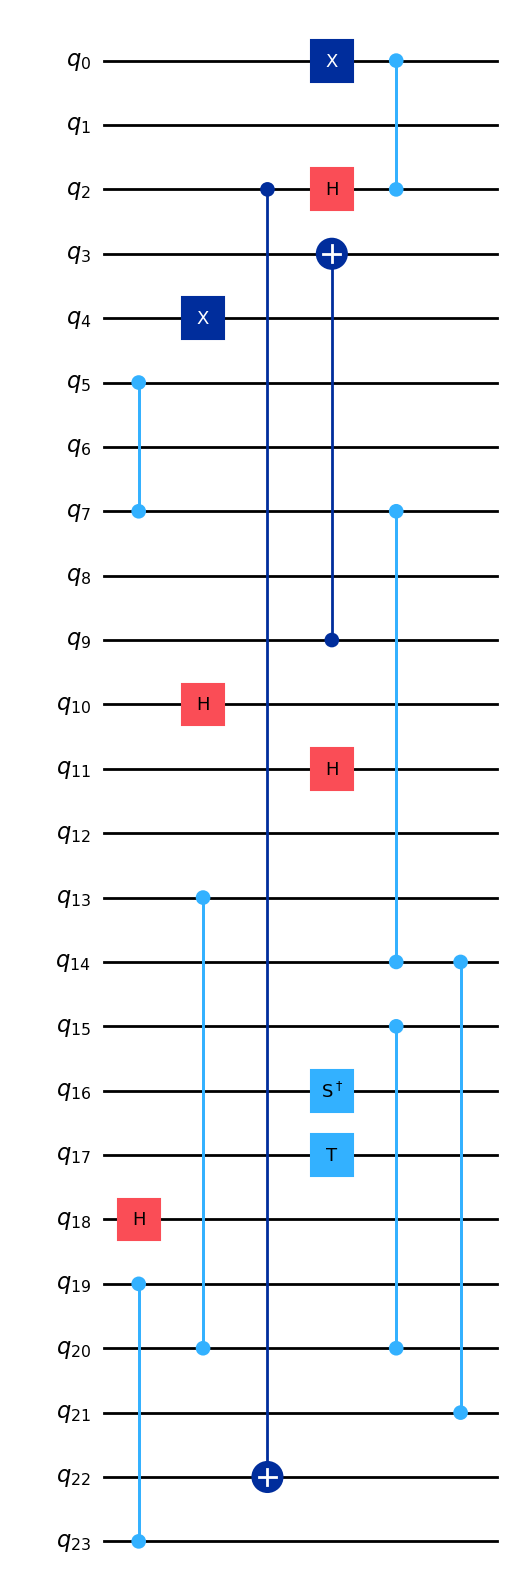

In [1]:
import random
from qiskit import QuantumCircuit
%load_ext autoreload
%autoreload 2

one_qubit_gates = ["h", "s", "sdg", "t", "tdg", "x", "z"]
two_qubit_gates = ["cx","cz",]

def random_circuit_generator(max_qubits, max_depth):
    qubits = random.randint(2, max_qubits)
    depth = random.randint(2, max_depth)
    qc = QuantumCircuit(qubits)

          
    for i in range(depth):
        if random.random() < 0.6:
            q = random.randrange(qubits)
            gate = random.choice(one_qubit_gates)
            getattr(qc, gate)(q)
        else:
            q1, q2 = random.sample(range(qubits), 2)
            gate = random.choice(two_qubit_gates)
            getattr(qc, gate)(q1, q2)

    return qc


qc = random_circuit_generator(60,30)
qc.draw("mpl")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


0
[]
1
[]
2
[]
3
[]
4
[]
5
[]
6
[]
7
[]
8
[]
9
[]
10
[]
11
[]
12
[]
13
[]
14
[]
15
[]
16
[]
17
[]
18
[]
19
[]
20
[]
21
[]
22
[]
23
[]
24
[]
25
['color_change']
26
['color_change']
27
['color_change']
28
['color_change']
29
['color_change']
30
['color_change']
31
['color_change']
32
['color_change']
33
['color_change']
34
['color_change']
35
['color_change']
36
[]
37
['color_change']
38
['color_change']
39
['color_change']
40
['color_change']
41
['color_change']
42
['color_change']
43
['color_change']
44
['color_change']
45
['color_change']
46
[]
47
[]
48
[]
49
[]
50
[]
51
[]
52
[]
53
[]
54
[]
55
[]
56
[]
57
[]
58
[]
59
[]
60
[]
61
[]
62
[]
63
[]
64
[]
65
[]
66
[]
67
[]
68
[]
69
[]


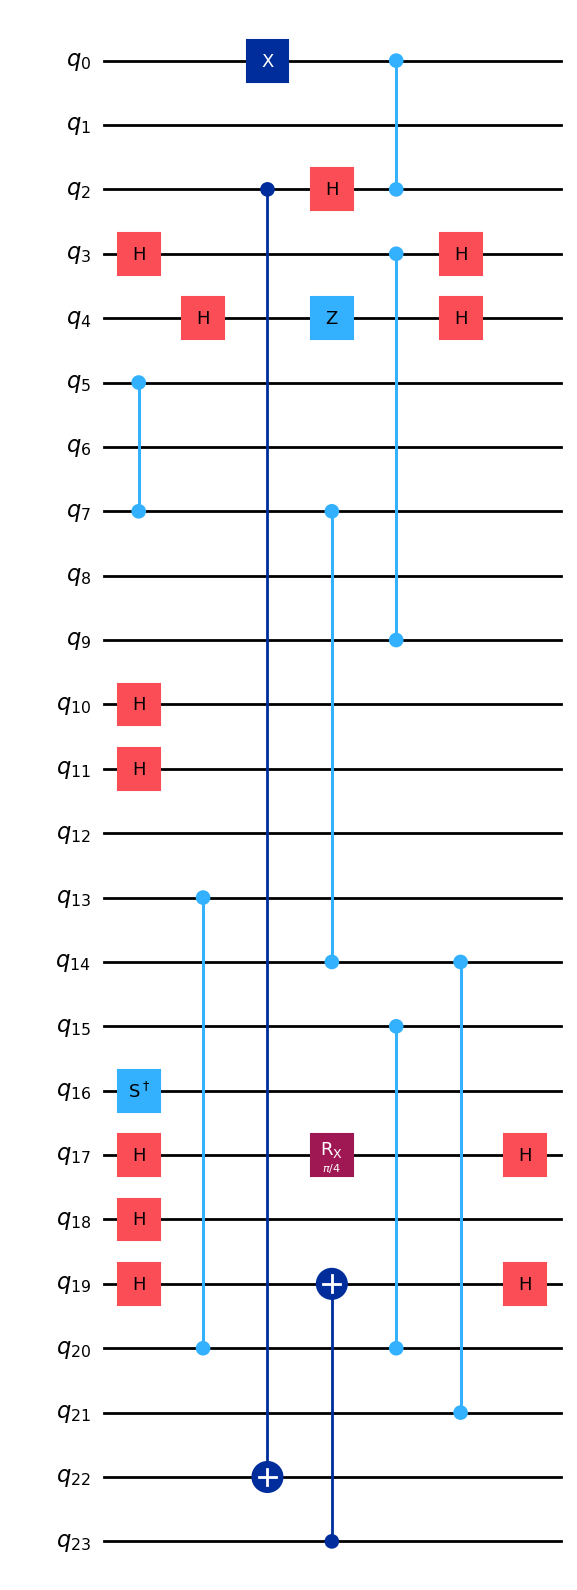

In [2]:
%load_ext autoreload
%autoreload 2

from qiskit.circuit.random import random_circuit
from quantum_optimiser import integration
from quantum_optimiser.multimetric import metrics
from quantum_optimiser.multimetric import loss
from quantum_optimiser.multimetric import simulated_annealing
from quantum_optimiser.multimetric import rewrite

from qiskit import transpile
import pyzx
from IPython.display import display



diagram = integration.qiskit_to_pyzx(qc)


best_circuit, best_diagram, best_cost, _ = simulated_annealing.simulated_annealing_zx(
                circuit=qc,
                cost_function=loss.log_weighted_loss,
                get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
                initial_temp=100.0,
                cooling_rate=0.95,
                max_iterations=1000,
                max_no_improvement=1000,
            )

pyzx.draw(diagram, labels = "true")
pyzx.draw(best_diagram, labels = "true")
for i in range (70):
    print(i)
    print(rewrite.get_applicable_rules(best_diagram,i))
    
circ = integration.pyzx_to_qiskit(best_diagram)
circ.draw("mpl")

# Evaluating the optimiser
The code below generates 10 random circuits of the same size, and prints out the average decrease in each cost function as well as the average decrease of each metric

In [3]:
import numpy as np

def get_metrics(circuit):
    return {
        "qubits": metrics.circuit_qubit_count(circuit),
        "two_qubit": metrics.circuit_two_qubit_gate_count(circuit),
        "gates": metrics.circuit_gate_count(circuit),
        "depth": metrics.circuit_depth(circuit),
        "t": metrics.circuit_t_gate_count(circuit),
    }

def evaluate_once(circuit, loss_fn):
    before_m = get_metrics(circuit)
    before_L = loss_fn(circuit)
    optimised_circuit, optimised_diagram, optimised_cost, _ =  simulated_annealing.simulated_annealing_zx(
                circuit=circuit,
                cost_function=loss_fn,
                get_neighbor=simulated_annealing.get_neighbor_weighted_rules,
                initial_temp=100.0,
                cooling_rate=0.95,
                max_iterations=500,
                max_no_improvement=50,
            )
    after_m = get_metrics(optimised_circuit)
    after_L = optimised_cost

    dL = before_L - after_L
    dm = {k: before_m[k] - after_m[k] for k in before_m}
    return dL, dm

def evaluate(n_circuits=10, qubits=100, depth=50):
    functions = {
        "naive": loss.naive_loss,
        "informed": loss.informed_loss,
        "log_weighted": loss.log_weighted_loss,
        "quadratic": loss.quadratic_loss_circuit
    }

    cost_deltas = {name: [] for name in functions}
    metric_deltas = {name: [] for name in functions}
    
    circuits = [random_circuit_generator(qubits, depth) for i in range(n_circuits)]
    for qc in circuits:
        for name,L in functions.items():
            dL, dm = evaluate_once(qc, L)
            cost_deltas[name].append(dL)
            metric_deltas[name].append(dm)

    print(f"\nBenchmark over {n_circuits} circuits | qubits={qubits} depth={depth}\n")

    for name in functions:
        avg_dL = float(np.mean(cost_deltas[name]))
        print(name)
        print(f"Avg cost decrease: {avg_dL:.4f}")

        keys = metric_deltas[name][0].keys()
        avg_metrics = {k: float(np.mean([m[k] for m in metric_deltas[name]])) for k in keys}
        for k, v in avg_metrics.items():
            print(f"  Avg {k} decrease: {v:.4f}")
        print()


evaluate()


Benchmark over 10 circuits | qubits=100 depth=50

naive
Avg cost decrease: 0.5600
  Avg qubits decrease: 0.1000
  Avg two_qubit decrease: 0.0000
  Avg gates decrease: 1.1000
  Avg depth decrease: 0.5000
  Avg t decrease: 1.1000

informed
Avg cost decrease: 0.7100
  Avg qubits decrease: 0.1000
  Avg two_qubit decrease: 0.0000
  Avg gates decrease: 0.0000
  Avg depth decrease: 0.0000
  Avg t decrease: 1.4000

log_weighted
Avg cost decrease: 6.9806
  Avg qubits decrease: 0.1000
  Avg two_qubit decrease: 0.0000
  Avg gates decrease: -17.4000
  Avg depth decrease: -0.9000
  Avg t decrease: 2.5000

quadratic
Avg cost decrease: 1.7120
  Avg qubits decrease: 0.1000
  Avg two_qubit decrease: 0.0000
  Avg gates decrease: -11.7000
  Avg depth decrease: -1.3000
  Avg t decrease: 2.4000



In [36]:
%load_ext autoreload
%autoreload 2
qc2 = random_circuit_generator(10,10)
print(qc2)    
diagram = integration.qiskit_to_pyzx(qc2)
x=simulated_annealing.get_neighbour_all_vertices(diagram)
print(x)
if "color_change" in x:
    print("yes")
else:
    print("no")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
                       
q_0: ──────────────────
          ┌───┐┌───┐   
q_1: ──■──┤ X ├┤ H ├─■─
     ┌─┴─┐└─┬─┘├───┤ │ 
q_2: ┤ X ├──┼──┤ Z ├─┼─
     └───┘  │  └───┘ │ 
q_3: ───────┼────────■─
     ┌───┐  │          
q_4: ┤ X ├──┼──────────
     └───┘  │          
q_5: ───────┼──────────
     ┌───┐  │          
q_6: ┤ H ├──┼──────────
     └───┘  │          
q_7: ───────■──────────
                       
q_8: ──────────────────
                       
q_9: ──────────────────
                       
[[0, []], [1, []], [2, []], [3, []], [4, []], [5, []], [6, []], [7, []], [8, []], [9, []], [10, ['color_change']], [11, []], [12, ['color_change', 'remove_id']], [13, ['color_change']], [14, []], [15, ['color_change', 'remove_id']], [16, ['color_change']], [17, ['color_change', 'fuse']], [18, ['color_change']], [19, ['color_change']], [20, []], [21, []], [22, []], [23, []], [24, []], [25, []], [26, []], [